In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import sys
import dask.dataframe as dd
import dask.array as da
from icecube import icetray, dataio, phys_services                                                                        
from icecube import dataclasses  
from matplotlib.colors import LogNorm
from scipy.stats import ks_2samp
import tables

sys.path.insert(0, "/data/user/akatil/electron_neutrino/for_real/analysis_chain/")

from analysis_helpers import get_mean_upgrade_positions

In [2]:
#getting the geometry frame. We want this to calculate the mean of upgrade om x and y positions
gcd_infile = dataio.I3File('/home/akatil/GeoCalibDetectorStatus_ICUpgrade.v58.mixed.V1.i3.bz2')

f_geo = gcd_infile
geo_frame = f_geo.pop_frame(icetray.I3Frame.Geometry)
geo = geo_frame['I3Geometry']

ux, uy, uz = get_mean_upgrade_positions(geo)

fCC = tables.open_file('../../../dataset_complete/merger/merged_CC_0.h5', mode='r')
fNC = tables.open_file('../../../dataset_complete/merger/merged_NC_0.h5', mode='r')

In [3]:
emin, emax = 0, 100
cmin, cmax = 0, 10

imin, imax = 0, 0.1

#interaction_type = 0

#f = fCC

def get_boolean(f, interaction_type):
    if interaction_type == 0:
        energy = f.root.OMMapTrue.col('om_penergy')

    if interaction_type == 1:
        energy = f.root.OMMapTrue.col('om_senergy')

    renergy = f.root.OMMapReco.col('om_renergy')
    total_charge = f.root.OMMapReco.col('om_total_charge')

    energy_boolean = (energy >= emin) & (energy <= emax)
    reco_energy_boolean = (renergy >= emin) & (renergy <= emax)
    total_charge_boolean = (total_charge >= cmin) & (total_charge <= cmax)

    om_boolean = energy_boolean
    reco_om_boolean = reco_energy_boolean

    return om_boolean, reco_om_boolean, total_charge_boolean

In [4]:
om_booleanCC, reco_om_booleanCC, total_charge_booleanCC = get_boolean(fCC, 0)
om_booleanNC, reco_om_booleanNC, total_charge_booleanNC = get_boolean(fNC, 1)

In [5]:
def make1D_histograms(trueCC, trueNC, recoCC, recoNC, label, mask=True, energy=True):

    if mask:
        min_val = -1
        max_val = 300
        
        true_maskCC = (trueCC>=min_val)&(trueCC<=max_val)
        true_maskNC = (trueNC>=min_val)&(trueNC<=max_val)

        reco_maskCC = (recoCC>=min_val)&(recoCC<=max_val)
        reco_maskNC = (recoNC>=min_val)&(recoNC<=max_val)
        
        trueCC = trueCC[true_maskCC]
        trueNC = trueNC[true_maskNC]

        recoCC = recoCC[reco_maskCC]
        recoNC = recoNC[reco_maskNC]
    
    trueCC = trueCC[~np.isnan(trueCC)]
    trueNC = trueNC[~np.isnan(trueNC)]

    recoCC = recoCC[~np.isnan(recoCC)]
    recoNC = recoNC[~np.isnan(recoNC)]

    ks_statistic_true, pvalue_true = ks_2samp(trueCC, trueNC)

    ks_statistic_reco, pvalue_reco = ks_2samp(recoCC, recoNC)

    combined_min = min(trueCC.min(), trueNC.min())
    combined_max = max(trueCC.max(), trueNC.max())

    n_bins = 100
    bin_edges = np.linspace(combined_min, combined_max, n_bins + 1)

    if energy:
        title = 'Energy {} - {} GeV'.format(emin, emax)
    else:
        title = 'Charge {} - {}'.format(emin, emax)
        
    plt.hist(trueCC, bins = bin_edges, histtype='step', log = True, density=True, label='CC', lw=1.5)
    plt.hist(trueNC, bins = bin_edges, histtype='step', log = True, density=True, label='NC', lw=1.5)
    plt.legend()
    plt.text(0.3, 0.65, r'KS statistic = ' + str(np.round(ks_statistic_true, 3)), transform=plt.gca().transAxes)
    plt.text(0.3, 0.60, r'p-value = ' + str(np.round(pvalue_true, 3)), transform=plt.gca().transAxes)
    plt.xlabel(label)
    plt.title(title+'|True') #plt.title('Energy {} - {} GeV|True'.format(emin, emax))

    plt.show()

    combined_min = min(recoCC.min(), recoNC.min())
    combined_max = max(recoCC.max(), recoNC.max())

    n_bins = 100
    bin_edges = np.linspace(combined_min, combined_max, n_bins + 1)

    plt.hist(recoCC, bins = bin_edges, histtype='step', log = True, density=True, label='CC', lw=1.5)
    plt.hist(recoNC, bins = bin_edges, histtype='step', log = True, density=True, label='NC', lw=1.5)
    plt.legend()
    plt.text(0.3, 0.65, r'KS statistic = ' + str(np.round(ks_statistic_reco, 3)), transform=plt.gca().transAxes)
    plt.text(0.3, 0.60, r'p-value = ' + str(np.round(pvalue_reco, 3)), transform=plt.gca().transAxes)
    plt.xlabel(label)
    plt.title(title+'|Reco') #plt.title('Energy {} - {} GeV|Reco'.format(emin, emax))

    plt.show()

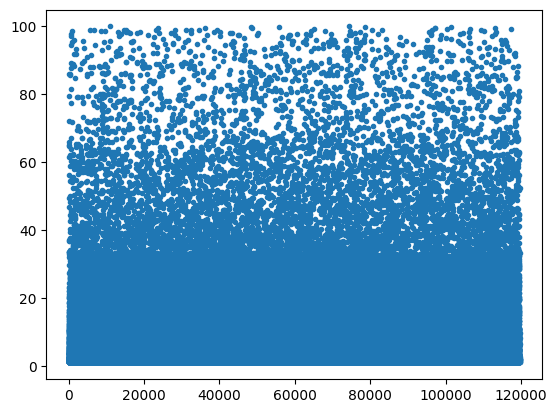

In [6]:
plt.plot(fCC.root.PrimaryEnergy.col('value'), '.')

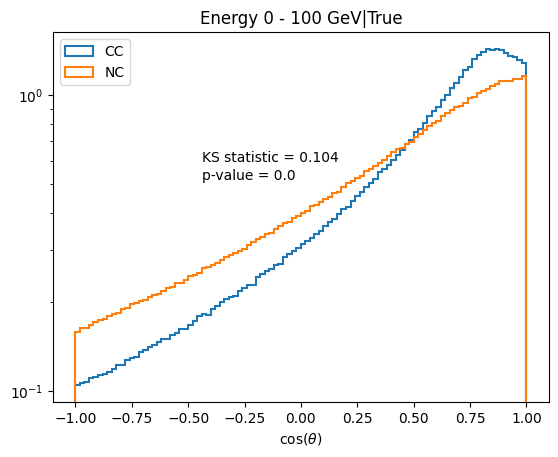

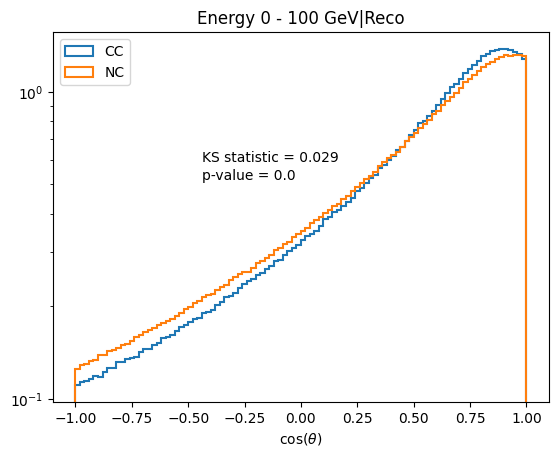

In [7]:
make1D_histograms(np.cos(fCC.root.OMMapTrue.col('angle')[om_booleanCC]), np.cos(fNC.root.OMMapTrue.col('angle')[om_booleanNC]),
                  np.cos(fCC.root.OMMapReco.col('angle')[reco_om_booleanCC]), np.cos(fNC.root.OMMapReco.col('angle')[reco_om_booleanNC]),
                  r'$\cos (\theta)$', mask=False)

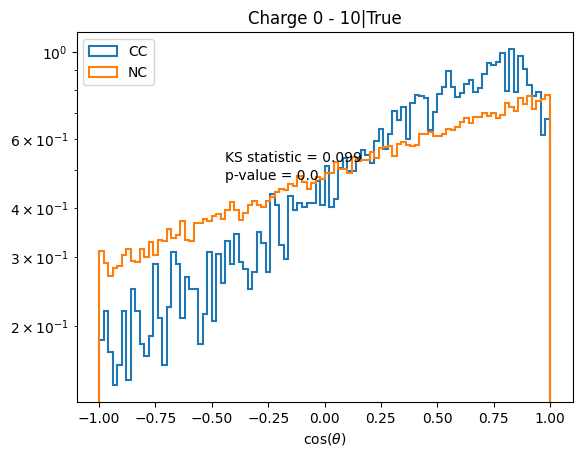

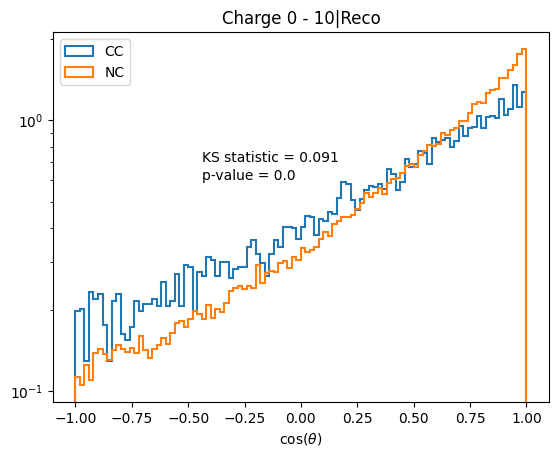

In [8]:
make1D_histograms(np.cos(fCC.root.OMMapTrue.col('angle')[total_charge_booleanCC]), np.cos(fNC.root.OMMapTrue.col('angle')[total_charge_booleanNC]),
                  np.cos(fCC.root.OMMapReco.col('angle')[total_charge_booleanCC]), np.cos(fNC.root.OMMapReco.col('angle')[total_charge_booleanNC]),
                  r'$\cos (\theta)$', mask=False, energy=False)

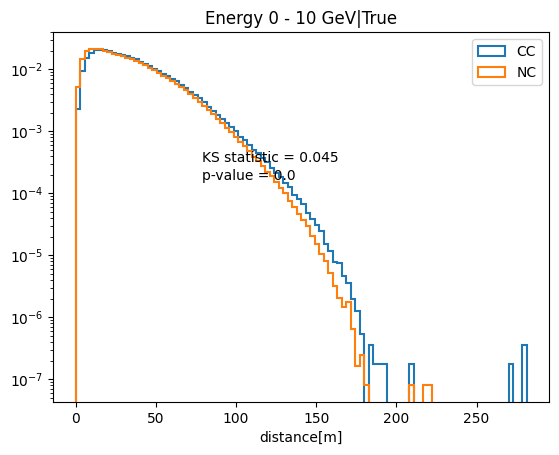

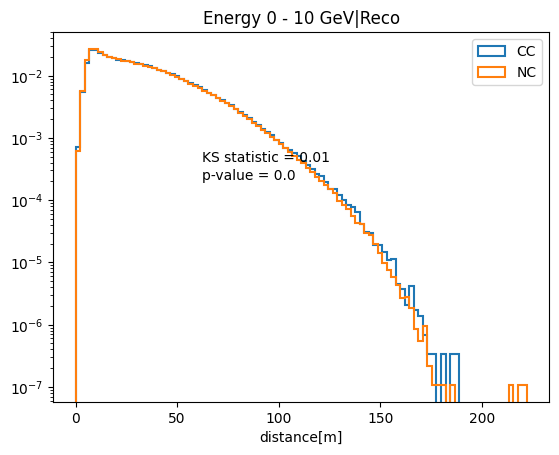

In [9]:
make1D_histograms(fCC.root.OMMapTrue.col('distance')[om_booleanCC], fNC.root.OMMapTrue.col('distance')[om_booleanNC],
                  fCC.root.OMMapReco.col('distance')[reco_om_booleanCC], fNC.root.OMMapReco.col('distance')[reco_om_booleanNC],
                  'distance[m]', mask=False)

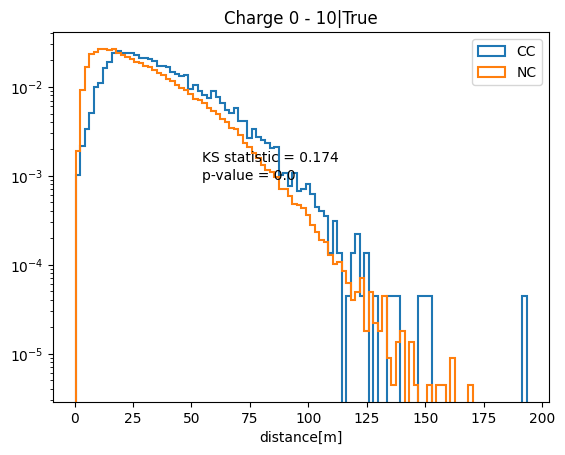

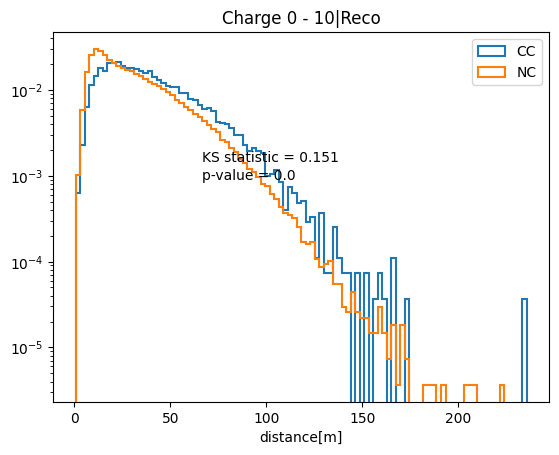

In [10]:
make1D_histograms(fCC.root.OMMapTrue.col('distance')[total_charge_booleanCC], fNC.root.OMMapTrue.col('distance')[total_charge_booleanNC],
                  fCC.root.OMMapReco.col('distance')[total_charge_booleanCC], fNC.root.OMMapReco.col('distance')[total_charge_booleanNC],
                  'distance[m]', mask=False, energy=False)

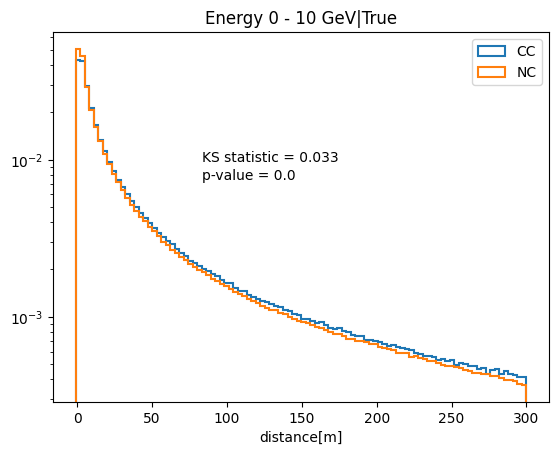

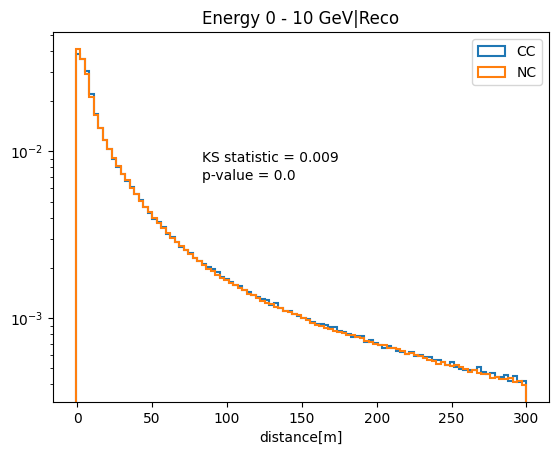

In [11]:
make1D_histograms(fCC.root.OMMapTrue.col('time_residual')[om_booleanCC], fNC.root.OMMapTrue.col('time_residual')[om_booleanNC],
                  fCC.root.OMMapReco.col('time_residual')[reco_om_booleanCC], fNC.root.OMMapReco.col('time_residual')[reco_om_booleanNC],
                  'distance[m]', mask=True)

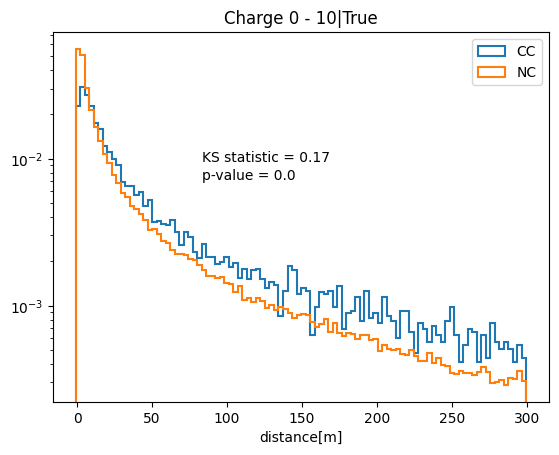

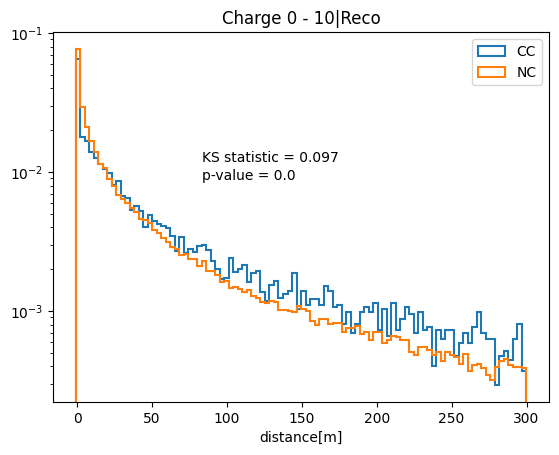

In [13]:
make1D_histograms(fCC.root.OMMapTrue.col('time_residual')[total_charge_booleanCC], fNC.root.OMMapTrue.col('time_residual')[total_charge_booleanNC],
                  fCC.root.OMMapReco.col('time_residual')[total_charge_booleanCC], fNC.root.OMMapReco.col('time_residual')[total_charge_booleanNC],
                  'distance[m]', mask=True, energy=False)